### Problem #1

In [66]:
def to_falsy(value):
    if isinstance(value, (list, dict, set, tuple)):
        print("non primitive type input")
        return
    elif isinstance(value, int):
        return 0
    elif isinstance(value, float):
        return 0.0
    elif isinstance(value, str):
        return ""
    elif isinstance(value, bool):
        return False
    elif isinstance(value, complex):
        return 0j
    else:
        return

In [67]:
# A list of values to test your function
challenge_cases = [
    42,             # Integer
    3.14159,        # Float
    "Python",       # String
    True,           # Boolean
    (1 + 2j),       # Complex
    None,           # NoneType
    [1, 2, 3],      # List (non-primitive)
    ('a', 'b'),     # Tuple (non-primitive)
    {'key': 'val'}  # Dictionary (non-primitive)
]

# Your code to iterate and print results goes here
for case in challenge_cases:
    print(f"{case} -> {to_falsy(case)}")

42 -> 0
3.14159 -> 0.0
Python -> 
True -> 0
(1+2j) -> 0j
None -> None
non primitive type input
[1, 2, 3] -> None
non primitive type input
('a', 'b') -> None
non primitive type input
{'key': 'val'} -> None


### Problem 2

In [68]:
def inspect_operations(arg1, arg2):
    print(type(arg1))
    print(type(arg2))

    try:
        print(arg1 + arg2)
    except Exception:
        print(f"cannot add")

    try:
        print(arg1 * arg2)
    except Exception:
        print(f"cannot multiply")
    
    try:
        type(arg2)(arg1)
    except Exception:
        print("cannot coerce")
    else:
        print("can coerce")

In [69]:
#base case 1
inspect_operations(10, 5)

#base case 2
inspect_operations(3, "hello")

<class 'int'>
<class 'int'>
15
50
can coerce
<class 'int'>
<class 'str'>
cannot add
hellohellohello
can coerce


In [70]:
# A list of argument pairs to test your function
challenge_cases = [
    (10.5, 2),
    ("repeat", 4),
    (True, 5),
    ([1, 2], 3),
    ("fizz", "buzz"),
    (None, "a_string"),
    ({'a': 1}, 2)
]

# Your code to iterate and test goes here.
# For each 'case' in the list, you can call your function
# like this: inspect_operations(*case)
for case in challenge_cases:
    print(f"Case: {case}")
    inspect_operations(*case)
    print()

Case: (10.5, 2)
<class 'float'>
<class 'int'>
12.5
21.0
can coerce

Case: ('repeat', 4)
<class 'str'>
<class 'int'>
cannot add
repeatrepeatrepeatrepeat
cannot coerce

Case: (True, 5)
<class 'bool'>
<class 'int'>
6
5
can coerce

Case: ([1, 2], 3)
<class 'list'>
<class 'int'>
cannot add
[1, 2, 1, 2, 1, 2]
cannot coerce

Case: ('fizz', 'buzz')
<class 'str'>
<class 'str'>
fizzbuzz
cannot multiply
can coerce

Case: (None, 'a_string')
<class 'NoneType'>
<class 'str'>
cannot add
cannot multiply
can coerce

Case: ({'a': 1}, 2)
<class 'dict'>
<class 'int'>
cannot add
cannot multiply
cannot coerce



In [71]:
def sort_and_separate_integers(data):
    if not isinstance(data, list):
        print("Input is not a list")
        return

    odd_list = []
    even_list = []
    non_integers = []

    for i, item in enumerate(data):
        if type(item) == int:
            if item % 2 == 0:
                even_list.append(item)
            else:
                odd_list.append(item)
        else:
            print(f"non-integer entry found at index {i}: {data[i]}")
            non_integers.append(item)

    if odd_list:
        odd_list.sort()

    if even_list:
        even_list.sort()

    return even_list, odd_list

In [72]:
sort_and_separate_integers([4, 3, 7, 10, 1, 8])

([4, 8, 10], [1, 3, 7])

In [73]:
sort_and_separate_integers([1, "hello", 2, 4])

non-integer entry found at index 1: hello


([2, 4], [1])

In [74]:
sort_and_separate_integers("this is not a list")

Input is not a list


In [75]:
# A list of inputs to test your function
challenge_cases = [
    [5, -2, 2, 5, "skip", -3, 8], # Mixed types, negatives, and duplicates
    [],                           # An empty list
    [10, 2, 88, 4],               # Only even integers
    [9, 15, 1, 3],                # Only odd integers
    ['a', None, 3.14, True],      # No valid integers (Note: True is a bool, not an int for this problem)
    (1, 2, 3),                    # A tuple, not a list
    [10]                          # A list with a single element
]

# Your code to iterate and test goes here.
# For each 'case' in the list, call your function
# and print the returned value.
for case in challenge_cases:
    print(sort_and_separate_integers(case))

non-integer entry found at index 4: skip
([-2, 2, 8], [-3, 5, 5])
([], [])
([2, 4, 10, 88], [])
([], [1, 3, 9, 15])
non-integer entry found at index 0: a
non-integer entry found at index 1: None
non-integer entry found at index 2: 3.14
non-integer entry found at index 3: True
([], [])
Input is not a list
None
([10], [])


In [76]:
def analyze_list_sets(l0, l1):
    if not isinstance(l0, list):
        print(f"invalid input: {l0}")
        return None
    if not isinstance(l1, list):
        print(f"invalid input: {l1}")
        return None

    primitives = (int, float, str, bool, complex, type(None))

    def clean(lst, name):
        out = []
        for i, v in enumerate(lst):
            if isinstance(v, primitives):
                out.append(v)
            else:
                print(f"invalid entry at index {i} in {name}: {v}")
        return out

    c0 = clean(l0, "l0")
    c1 = clean(l1, "l1")

    s0, s1 = set(c0), set(c1)
    inter = s0.intersection(s1)
    symdiff = s0.symmetric_difference(s1)

    def order(target_set):
        try:
            return sorted(target_set)
        except TypeError:
            # mixed, non-comparable types: fall back to first-seen order
            # scanning l0 then l1
            seen = []
            for v in c0 + c1:
                if v in target_set and v not in seen:
                    seen.append(v)
            return seen

    return (order(inter), order(symdiff))

In [77]:


print("Base case 1:")
print(analyze_list_sets([1, 'a', 3], [3, 'b', 'a']))
print()
print("Base case 2:")
print(analyze_list_sets([1, 2], "not-a-list"))
print()
print("Base case 3:")
print(analyze_list_sets([1, [99], 2, 3], [2, 4, 3]))

print()
print("Challenge cases:")
challenge_cases = [
    ([1, 'a', 2.0], ['a', 3, 2.0]),
    ([1, 2], [1, 2, 3, 4]),
    ([1, None, {'k': 'v'}], [1, 2, None]),
    ([1, 2, 3], [4, 5, 6]),
    ([], [1, 2, 3]),
    ("not a list", [1, 2]),
    ([1, 2], [1, 2])
]

for case in challenge_cases:
    result = analyze_list_sets(*case)
    print(f"{case} -> {result}")
    print()

Base case 1:
(['a', 3], [1, 'b'])

Base case 2:
invalid input: not-a-list
None

Base case 3:
invalid entry at index 1 in l0: [99]
([2, 3], [1, 4])

Challenge cases:
([1, 'a', 2.0], ['a', 3, 2.0]) -> (['a', 2.0], [1, 3])

([1, 2], [1, 2, 3, 4]) -> ([1, 2], [3, 4])

invalid entry at index 2 in l0: {'k': 'v'}
([1, None, {'k': 'v'}], [1, 2, None]) -> ([1, None], [2])

([1, 2, 3], [4, 5, 6]) -> ([], [1, 2, 3, 4, 5, 6])

([], [1, 2, 3]) -> ([], [1, 2, 3])

invalid input: not a list
('not a list', [1, 2]) -> None

([1, 2], [1, 2]) -> ([1, 2], [])



### Problem 5

In [78]:
import numpy as np

def summarize_numpy_array(arr):
    if not isinstance(arr, np.ndarray) or arr.ndim != 1 or not np.issubdtype(arr.dtype, np.floating):
        print("invalid input")
        return None

    if arr.size == 0:
        return {
            'min': None,
            'mean': None,
            'max': None,
            'std_dev': None,
            'p25': None,
            'p50': None,
            'p75': None,
            'iqr': None
        }

    p25 = np.percentile(arr, 25)
    p75 = np.percentile(arr, 75)

    return {
        'min': np.min(arr),
        'mean': np.mean(arr),
        'max': np.max(arr),
        'std_dev': np.std(arr),
        'p25': p25,
        'p50': np.percentile(arr, 50),
        'p75': p75,
        'iqr': p75 - p25
    }

In [79]:
# A list of inputs to test your function
challenge_cases = [
    np.array([10.5, 2.3, -5.7, 8.1, 0.0, 3.9]), # Standard case with negatives
    np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]), # Another valid case
    np.array([], dtype=np.float64),              # Edge case: empty but valid array
    [1.0, 2.0, 3.0],                             # Invalid: Python list
    np.array([[1.0, 2.0], [3.0, 4.0]]),          # Invalid: 2D array
    np.arange(5)                                 # Invalid: integer dtype
]

for case in challenge_cases:
    print(summarize_numpy_array(case))

{'min': np.float64(-5.7), 'mean': np.float64(3.183333333333333), 'max': np.float64(10.5), 'std_dev': np.float64(5.2922637458421855), 'p25': np.float64(0.575), 'p50': np.float64(3.0999999999999996), 'p75': np.float64(7.05), 'iqr': np.float64(6.475)}
{'min': np.float64(1.0), 'mean': np.float64(4.5), 'max': np.float64(8.0), 'std_dev': np.float64(2.29128784747792), 'p25': np.float64(2.75), 'p50': np.float64(4.5), 'p75': np.float64(6.25), 'iqr': np.float64(3.5)}
{'min': None, 'mean': None, 'max': None, 'std_dev': None, 'p25': None, 'p50': None, 'p75': None, 'iqr': None}
invalid input
None
invalid input
None
invalid input
None


### Problem 6

In [80]:
import numpy as np
import matplotlib.pyplot as plt

def create_scatter_plot(x_arr, y_arr):
    if not isinstance(x_arr, np.ndarray) or x_arr.ndim != 1 or not np.issubdtype(x_arr.dtype, np.floating):
        print("invalid input")
        return
    if not isinstance(y_arr, np.ndarray) or y_arr.ndim != 1 or not np.issubdtype(y_arr.dtype, np.floating):
        print("invalid input")
        return

    if len(x_arr) != len(y_arr):
        print("arrays are not the same size.")
        return

    x_masked = np.ma.masked_invalid(x_arr)
    y_masked = np.ma.masked_invalid(y_arr)

    x_filled = x_masked.filled(x_masked.mean())
    y_filled = y_masked.filled(y_masked.mean())

    plt.scatter(x_filled, y_filled)
    plt.title("Scatter Plot")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

Matplotlib is building the font cache; this may take a moment.


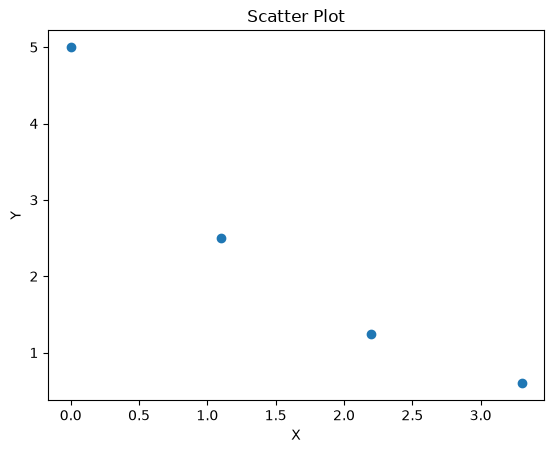

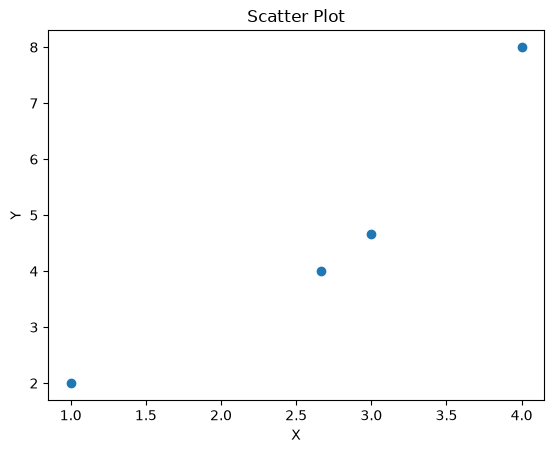

arrays are not the same size.
invalid input


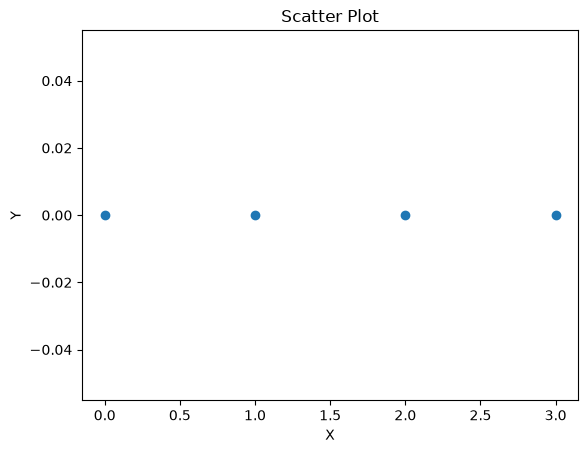

In [81]:
# A list of argument pairs to test your function
challenge_cases = [
    (np.array([0.0, 1.1, 2.2, 3.3]), np.array([5.0, 2.5, 1.25, 0.6])), # Standard case
    (np.array([1.0, np.nan, 3.0, 4.0]), np.array([2.0, 4.0, np.nan, 8.0])), # NaNs in both
    (np.array([1.0, 2.0]), np.array([1.0, 2.0, 3.0])),                     # Different lengths
    ([1.0, 2.0], np.array([3.0, 4.0])),                                   # Invalid type (list)
    (np.arange(4, dtype=float), np.array([np.nan, np.nan, np.nan, np.nan])) # All NaNs in one array
]

for case in challenge_cases:
    create_scatter_plot(*case)

### Problem 7

In [82]:
import numpy as np

def calculate_regression(x, y):
    if not isinstance(x, np.ndarray) or x.ndim != 1 or not np.issubdtype(x.dtype, np.floating):
        print("invalid input")
        return None
    if not isinstance(y, np.ndarray) or y.ndim != 1 or not np.issubdtype(y.dtype, np.floating):
        print("invalid input")
        return None

    if len(x) != len(y):
        print("x and y are not the same length")
        return None

    x_masked = np.ma.masked_invalid(x)
    y_masked = np.ma.masked_invalid(y)

    x_clean = x_masked.filled(x_masked.mean())
    y_clean = y_masked.filled(y_masked.mean())

    x_mean = np.mean(x_clean)
    y_mean = np.mean(y_clean)

    numerator = np.sum((x_clean - x_mean) * (y_clean - y_mean))
    denominator = np.sum((x_clean - x_mean) ** 2)

    slope = numerator / denominator
    intercept = y_mean - slope * x_mean

    return (slope, intercept)

In [83]:
# A list of argument pairs to test your function
challenge_cases = [
    (np.array([1.0, 2.0, 4.0, 5.0]), np.array([1.0, 3.0, 3.0, 5.0])), # Standard case
    (np.array([1.0, 2.0, 3.0, np.nan]), np.array([5.0, 4.0, np.nan, 2.0])), # NaNs in both
    (np.array([1.0, 2.0]), np.array([1.0, 2.0, 3.0])),                     # Different lengths
    ([1.0, 2.0], np.array([3.0, 4.0])),                                   # Invalid type (list)
    (np.arange(4, dtype=float), np.array([5.0, 5.0, 5.0, 5.0])),           # Horizontal line
    (np.array([5.0, 5.0, 5.0, 5.0]), np.arange(4, dtype=float))            # Vertical line
]

for case in challenge_cases:
    print(calculate_regression(*case))

(np.float64(0.8), np.float64(0.5999999999999996))
(np.float64(-0.6666666666666667), np.float64(5.0))
x and y are not the same length
None
invalid input
None
(np.float64(0.0), np.float64(5.0))
(np.float64(nan), np.float64(nan))


C:\Users\M315532\AppData\Local\Temp\ipykernel_27552\3303643678.py:27: RuntimeWarning: invalid value encountered in scalar divide
  slope = numerator / denominator


### Problem 8

In [84]:
import numpy as np
import matplotlib.pyplot as plt

def plot_regression(x, y):
    result = calculate_regression(x, y)
    if result is None:
        return

    slope, intercept = result

    if np.isnan(slope):
        print("vertical line detected")
        return None

    x_masked = np.ma.masked_invalid(x)
    y_masked = np.ma.masked_invalid(y)

    x_filled = x_masked.filled(x_masked.mean())
    y_filled = y_masked.filled(y_masked.mean())

    fig, ax = plt.subplots()
    ax.scatter(x_filled, y_filled)
    ax.axline(xy1=(0, intercept), slope=slope)
    ax.set_title("Linear Regression")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.show()

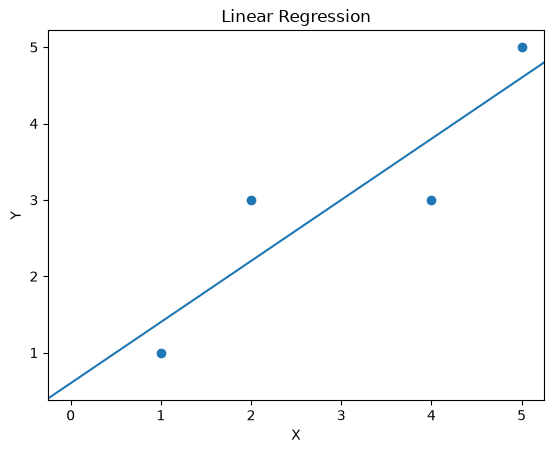

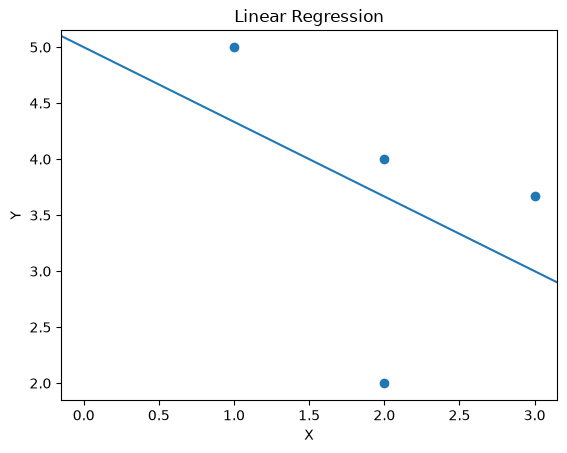

x and y are not the same length


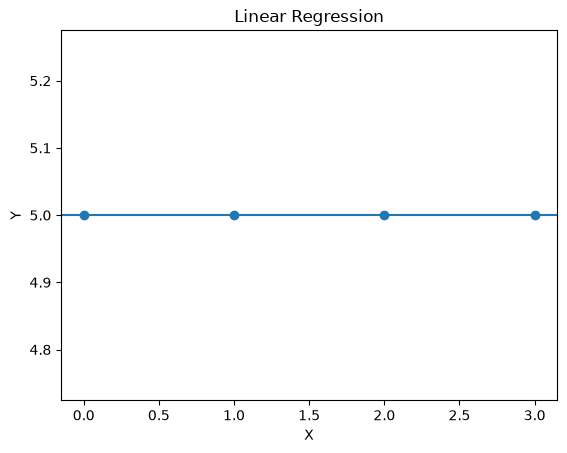

vertical line detected


C:\Users\M315532\AppData\Local\Temp\ipykernel_27552\3303643678.py:27: RuntimeWarning: invalid value encountered in scalar divide
  slope = numerator / denominator


In [85]:
# A list of argument pairs to test your function
challenge_cases = [
    (np.array([1.0, 2.0, 4.0, 5.0]), np.array([1.0, 3.0, 3.0, 5.0])), # Standard case
    (np.array([1.0, 2.0, 3.0, np.nan]), np.array([5.0, 4.0, np.nan, 2.0])), # NaNs in both
    (np.array([1.0, 2.0]), np.array([1.0, 2.0, 3.0])),                     # Different lengths
    (np.arange(4, dtype=float), np.array([5.0, 5.0, 5.0, 5.0])),           # Horizontal line
    (np.array([5.0, 5.0, 5.0, 5.0]), np.arange(4, dtype=float))            # Vertical line
]

for case in challenge_cases:
    plot_regression(*case)